# Nicht-lineare Dynamik [MUSTERLÖSUNG]

<div style = "background-color:  #f9e79f ; padding: 15px; border-radius: 8px;">
<div style="text-align: justify">
Dieses Notebook knüpft an das Notebook "Das Fadenpendel ohne Kleinwinkelnäherung" an. Das Hauptthema "Numerisches Lösen von Differentialgleichungen (DGLn)" wird hierbei auf das Gebiet der nicht-linearen Dynamik erweitert. Blaumarkierte Ausdrücke enthalten Links zu weiterführenden Internetseiten.
</div><br/>   
    
**Python Grundlagen:** <code>[math](https://docs.python.org/3/library/math.html)-Modul</code> (Fakultät), Definition einfacher Funktionen, einfache Schleifen, <code>[matplotlib.pyplot](https://matplotlib.org/stable/tutorials/introductory/pyplot.html)-Modul</code> (einfache Plots).<br>
**Einführung in:** <code>[SymPy](https://docs.sympy.org/latest/index.html)-Paket</code> (Python-Bibliothek für symbolisch-mathematische Berechnungen.), <code>[SciPy-odeint](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.odeint.html)-Funktion</code> (Integriert ein System gewöhnlicher Differentialgleichungen)<br>
**Math. Grundlagen:** Gewöhnliche Differentialgleichungen, Taylor-Entwicklung <br>
**Verwendete Literatur:** "<i>Nichtlineare Systeme in der klassischen Mechanik</i>", Bachelorarbeit, M. Lohöfer; "<i>Chaotic Dynamics (an introduction)</i>", 2nd Edition, G.L. Baker and J.P. Gollub; "<i>Das Gelbe Rechenbuch 1</i>", Peter Furlan;

**Ausgabedatum:** 01.03.2023 <br>
**Abgabedautm:** 01.04.2023 <br>
Für Rückfragen zum Übungsbetrieb wenden Sie sich an: mustermann@uni-muster.de

## Das gedämpfte, getriebene Pendel und der Duffing-Oszillator

<div style="text-align: justify">
Wir betrachten zunächst wieder das Fadenpendel mit Fadenlänge $l$, jedoch sowohl mit einem zusätzlichen Dämpfungsterm $( \propto \dot{\varphi})$ als auch einer extern treibenden cosinusförmigen Kraft. Das dynamische System wird durch die folgende, nicht-lineare, DGL 2.Ord. beschrieben:
</div><br/>

\begin{equation*}
    \ddot{\varphi}(t) + 2 \gamma \dot{\varphi}(t) + \omega_0^2 \sin \big( \varphi(t) \big) = A \cos \big( \omega_{\text{ext}} t \big) \quad \text{mit} \quad \omega_0^2 = \frac{g}{l}~.
    \label{eq:org_pendulum} \tag{1}
\end{equation*}


<div style="text-align: justify">
Für weitere Zwecke möchten wir den Term $\sin ( \varphi )$ in einer Taylorreihe um den Punkt $\varphi_0 = 0$ bis zur einer gewünschten Ordnung in $\varphi$ entwickeln (siehe auch Kleinwinkelnäherung bzw. Linearisierung der Fadenpendel-DGL). Für hinreichend harmlose Funktionen ist diese Entwicklung immer möglich. Wir interessieren uns hier jedoch nicht für den numerischen Wert, sondern für den formalen Ausdruck dieser Entwicklung. Das bedeutet, dass nun mathematische Ausdrücke in der analytischen und nicht in der numerischen Darstellung vorliegen sollen. Um den Umgang mit symbolisch-mathematischer Berechnung ("Rechnen mit Buchstaben") zu erlernen bzw. zu vertiefen, verwenden wir hierzu das Python-Paket <code>SymPy</code>. In der folgenden kurzen Aufgabe werden wir den aus der Literatur bekannten Ausdruck der Taylorreihe der Sinus-Funktion auf zwei verschiedene Arten erarbeiten. </div>

<div style= "color: black;background-color: #d6eaf8 ;margin: 10 px auto; padding: 10px; border-radius: 10px">
    <p style="font-size:12pt; text-align:center; color:   black; background-color: lightskyblue ;margin: 10 px auto; padding: 10px; border-radius: 10px" id="1"><b>  Aufgabe 1 </b>  </p> 
   
<div style="text-align: justify">    
Entwickeln Sie die Funktion $f(x) = \sin x$ um den Entwicklungspunkt $x_0 = 0$ als ein Taylorpolynom einschließlich bis zur Ordnung $n=10$. Nützlich für die Bearbeitung dieser Aufgabe sind: <code>sympy.diff</code> (<a href="https://docs.sympy.org/latest/tutorials/intro-tutorial/calculus.html">Calculus-Doc</a>), <code>sympy.series</code> (<a href="https://docs.sympy.org/latest/modules/series/series.html">Series Expansions-Doc</a>) und die <code>subs</code>-Methode (<a href="https://docs.sympy.org/latest/tutorials/intro-tutorial/basic_operations.html">Basic Operations-Doc</a>).<br><br/>
<b>Teilaufgabe a)</b><br/>
Definieren Sie eine Funktion <code>f</code>, welche die Variable $x$ entgegennimmt und den Wert des Sinus an der Stelle $x$ ausgibt. Verwenden Sie hierzu die Sinus-Funktion aus dem <code>SymPy</code>-Paket (WICHTIG)! <br><br/>
<b>Teilaufgabe b)</b><br/>
Des Weiteren definieren Sie eine Funktion <code>f_approx</code>, die mit Hilfe einer <code>for</code>-Schleife das Taylorpolynom $n$-ter Ordnung einer beliebigen (hinreichend harmlosen) Funktion $f(x)$ berechnet. Verwenden Sie $x_0$ und $n$ als Eingangsvariablen. <br><br/>
<b>Teilaufgabe c)</b><br/>
Vergleichen Sie das Ergebnis mit <code>sympy.series(f(x), x, x0, n))</code>.</div>
</div>    

**a)**

In [1]:
import math 
import sympy as sym #symbolisches Rechnen

def f(x):
    return sym.sin(x)

**b)**

In [2]:
def f_approx(x_0, n):
    x=sym.Symbol("x") # x ist als symbolische Variable deklariert (WICHTIG)
    sum=f(x_0)
    dfdx = sym.diff(f(x), x)
    for i in range(1, n+1):
        dfdx_x0 = dfdx.subs(x, 0)
        sum = sum + dfdx_x0 / math.factorial(i) * (x-x_0)**(i)
        dfdx = sym.diff(dfdx, x)
    return sum

**c)**

In [3]:
x=sym.Symbol("x") # x ist als symbolische Variable deklariert (WICHTIG)
print("f_approx"+" "*9+"= ",f_approx(0,10)) # Näherung an der Stelle 0 bis zur 10. Ordung
print("via SymPy-series = ", sym.series(f(x), x, 0, 11)) # Näherung an der Stelle 0 bis zur 10. Ordung

f_approx         =  x**9/362880 - x**7/5040 + x**5/120 - x**3/6 + x
via SymPy-series =  x - x**3/6 + x**5/120 - x**7/5040 + x**9/362880 + O(x**11)


<div style=" border: 2px solid green;margin: 10px auto; padding: 10px; border-radius: 10px; background-color: beige;">
<div style="text-align: justify">
Da der Sinus eine ungerade Funktion in $x$ ist, werden natürlich nur die ungeraden Terme bis zur gewünschten Ordnung berechnet und ausgegeben.
</div>

<hr style="width:50%"> 
<div style="text-align: justify">
Mit der Taylor-Entwicklung des Sinus bis zur dritten Ordnung in $\theta$ erhalten wir die folgende Gleichung
</div><br/>

\begin{equation*}
    \ddot{\varphi}(t) + 2 \gamma \dot{\varphi}(t) + \omega_0^2 \bigg( \varphi(t) - \frac{1}{6} \varphi^3(t) \bigg) = A \cos \big(\omega_{\text{ext}} t \big)~.
    \label{eq:pendulum_Taylor} \tag{2}
\end{equation*}

<div style="text-align: justify">
Gleichung $\eqref{eq:pendulum_Taylor}$ stellt die DGL eines nicht-linearen <strong>Duffing-Oszillators</strong> dar. Die allgemeine Form dieser DGL ist gegeben durch
</div><br/>

\begin{equation*}
\ddot{\varphi}(t) + \delta \dot{\varphi}(t) + \alpha \varphi(t) + \beta \varphi^3(t) = \gamma \cos \big( \omega_{\text{ext}} t \big)~,
\label{eq:Duffing}\tag{3}
\end{equation*}

<div style="text-align: justify">
wobei $\delta$ die Dämpfung, $\gamma$, $\omega_{\text{ext}}$ die Amplitude und die Frequenz der externen Anregung, $\alpha$ die Stärke der linear rückstellenden Kraft und $\beta$ die Nicht-linearität charakterisieren. Mit $\alpha = \omega_0^2$ (d.h. $\alpha > 0$) und $\beta = - \omega_0^2/6$ (d.h. $\beta < 0$) erhalten wir den Fall aus Gleichung $\eqref{eq:pendulum_Taylor}$. Diese Gleichung beschreibt einen harmonischen Oszillator mit einer zusätzlichen nichtlinearen Korrektur (Störung) niedriger Ordnung. Das dynamische System besitzt selbst in Abwesenheit einer dissipativen und treibenden Kraft ein komplizierteres Potential (Parabelform ist nicht mehr gegeben). Im Allgemeinen können die Parameter $\alpha$ und $\beta$ beliebig gewählt werden, was dazu führen wird, dass wir uns vom bekannten physikalischen Fadenpendel distanzieren werden. Diesen Sachverhalt werden wir später nocheinmal aufgreifen.

Die Anzahl der in der DGL $\eqref{eq:Duffing}$ einstellbaren Parameter lässt sich mit Hilfe einer Skalentransformation von fünf auf drei reduzieren (siehe auch Buckingham'sches $\pi$-Theorem). Für den Fall mit $\alpha > 0$ erhalten wir
</div>

\begin{equation*}
\theta^{\prime \prime}(\tau) + 2 \eta \theta^{\prime}(\tau) + \theta(\tau) + \epsilon \theta^3(\tau) = \cos (\sigma \tau)~ \quad \text{mit} \quad \cfrac{\mathrm{d}}{\mathrm{d} \tau} \theta(\tau) = \theta^{\prime} (\tau)~.
\label{eq:Duffing_scaled}\tag{4}
\end{equation*}

<div style="text-align: justify">
Hierbei beschreibt $\eta$ den Dämpfungsparameter, $\epsilon$ die Nicht-linearität und $\sigma$ die Frequenz der externen Anregung. ACHTUNG: alle Größen sind in dieser Parametrisierung dimensionslos.
</div><br/>

<div style= "color: black;background-color: #d6eaf8 ;margin: 10 px auto; padding: 10px; border-radius: 10px">
<p style="font-size:12pt; text-align:center; color:   black; background-color: lightskyblue ;margin: 10 px auto; padding: 10px; border-radius: 10px" id="1"><b>  Aufgabe 2 </b>  </p> 
    Leiten Sie die Gl. \eqref{eq:Duffing_scaled} her. Zum E-Test (auf RWTH Moodle) gelangen Sie <a href="https://moodle.rwth-aachen.de/mod/quiz/view.php?id=1287039">HIER</a>.
</div>    

<div style=" border: 2px solid green;margin: 10px auto; padding: 10px; border-radius: 10px; background-color: beige;">
    <b>Lösung:</b> 

\begin{equation*}
\dot{\varphi}(t) = \dot{\tau} \frac{\mathrm{d}}{\mathrm{d} \tau} \theta (\tau) = \dot{\tau} \theta^{\prime}(\tau) = \sqrt{\alpha}\, \theta^{\prime}(\tau) \quad \Rightarrow \quad \ddot{\varphi}(t) = \alpha \theta^{\prime \prime}(\tau) \qquad \text{mit} \qquad \tau(t) = \sqrt{\alpha} t~, \quad \theta(\tau) = \cfrac{\alpha}{\gamma} \varphi(t), \quad \eta = \frac{\delta}{2 \sqrt{\alpha}}, \quad \epsilon = \frac{\beta \gamma^2}{\alpha^3}, \quad \sigma = \frac{\omega_{\text{ext}}}{\sqrt{\alpha}}~.
\end{equation*}

<hr style="width:50%">
<div style="text-align: justify">    
Für verschieden große Auslenkungswinkel lässt sich die Korrespondenz zum harmonischen Oszillator $\big($ohne $\theta^3$-Term$\big)$ herstellen. Mit dem Konzept des <strong>Phasenraums</strong> kann man dies sehr gut visualisieren.</div>  <br> 
<div style=" border: 2px solid black; margin: 10px auto; padding: 10px; border-radius: 10px; background-color: #f4ecf7;">
    <b>Phasenraum (kurz):</b> 
<ul> 
<div style="text-align: justify">    
Beschreibt die Menge aller Möglichen Zustände eines dynamischen Systems. Im Allgemeinen ist der Phasenraum $2n$-dimensional. Der Zustand eines dynamischen Systems ist durch einen Punkt bestehend aus einem Tupel aus $n$ verallgemeinerten Ortskoordinaten $x_i(t)$ und den $n$ dazugehörigen verallgemeinerten Geschwindigkeitskoordinaten $v_i(t)$ eindeutig im Phasenraum festgelegt. Die zeitliche  Entwicklung eines Punktes wird durch Differentialgleichungen erster Ordnung beschrieben und durch Trajektorien im Phasenraum dargestellt. 
</div>    
</div>
    
<div style="text-align: justify">    
Mit Hilfe der folgenden Überlegung lässt sich nun eine (nicht)-lineare DGL zweiter Ordnung auf zwei DGLn erster Ordnung reduzieren:    
</div><br/>    
    
\begin{equation*}
\theta^{\prime}(\tau) = \omega(t) \quad \text{und} \quad \omega^{\prime}(\tau) = \tilde{F}\big(\theta, \omega \big) 
\label{eq:pTay_spec_1stOrd} \tag{5}
\end{equation*}
   
<div style="text-align: justify">        
wobei $\tilde{F}(\theta, \omega)$ eine beliebige Funktion beider Koordinaten beschreibt. Des Weiteren definieren wir das (Phasenraum-) Geschwindigkeitsfeld
</div><br/>
    
\begin{equation*}
\vec{f}(\theta, \omega) = 
    \begin{pmatrix}
        \theta^{\prime}(\tau) \\
        \omega^{\prime}(\tau) 
    \end{pmatrix}~.  
\label{eq:vVec_gen} \tag{6}
\end{equation*}
  
<div style="text-align: justify">        
Mit Hilfe von $\vec{f}(\theta, \omega)$ kann nun das Verhalten der Phasenraumtrajektorie direkt abgelesen werden, da diese in einem Punkt $(\theta,\omega)^{T}$ tangential zu $\vec{f}(\theta,\omega)$ liegt. In der folgenden Aufgabe werden wir nun diesen Sachverhalt visualisieren.
</div><br/>

<div style= "color: black;background-color: #d6eaf8 ;margin: 10 px auto; padding: 10px; border-radius: 10px">
<p style="font-size:12pt; text-align:center; color:   black; background-color: lightskyblue ;margin: 10 px auto; padding: 10px; border-radius: 10px" id="1"><b>  Aufgabe 3 </b>  </p> 
<div style="text-align: justify">     
Gegeben ist ein nicht-getriebener gedämpfter harmonischer Oszillator. Verwenden Sie hierzu Gl. (4) und reduzieren Sie diese auf den gewünschten Fall. Berechnen Sie die Lösung der DGL mit Hilfe der <code>odeint</code>-Funktion aus dem <code>SciPy</code>-Paket (<a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.odeint.html">odeint-Doc</a> $\longrightarrow$ schauen Sie sich bitte das Beispiel genauer an).<br/>
<br>
<div style="text-align: justify">
<b>Teilaufgabe a)</b><br/>
Definieren Sie hierzu eine Funktion <code>f_HOdamped</code>, welche das Geschwindigkeitsfeld aus Gl. (6) berechnet und die folgenden Parameter entgegennimmt : <code>iniVal</code> (Array mit Anfangsbedingungen), <code>t</code> (Zeitintervall), weitere Systemparameter.<br><br/>
</div>
<div style="text-align: justify">
<b>Teilaufgabe b)</b><br/>
Lösen Sie die DGL numerisch für ein Zeitinterval $\tau \in [0, 50]$ (mit geeigneter Auflösung). Erstellen Sie ein $\theta(\tau)$-$\omega(\tau)$-Phasenraumdiagramm welches die Phasemraumtrajektorie und gleichzeitig das zugehörige Geschwindigkeitsfeld für die folgenden Systemparameter und Anfangsbedingungen darstellt: $\eta = 0.1$, $\theta (0) = 1.0$ und $\omega(0) = 0.0~.$
Um das Geschwindigkeitsfeld zu plotten, verwenden Sie bitte die <code>numpy.meshgrid</code> (<a href="https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html">meshgrid-Doc</a>)- und die <code>pyplot.quiver</code> (<a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.quiver.html">quiver-Doc</a>)-Funktionen.
</div>
</div>

**a)**

In [4]:
### import fast numerics
import numpy as np
### import the routine for ODE integration
from scipy.integrate import odeint
def f_HOdamped(iniVal, t, eta):
    fHOres = np.zeros_like(iniVal)
    x = iniVal[0]
    v = iniVal[1]
    fHOres[0] = v
    fHOres[1] = -2*eta*v - x
    
    return fHOres

**b)**

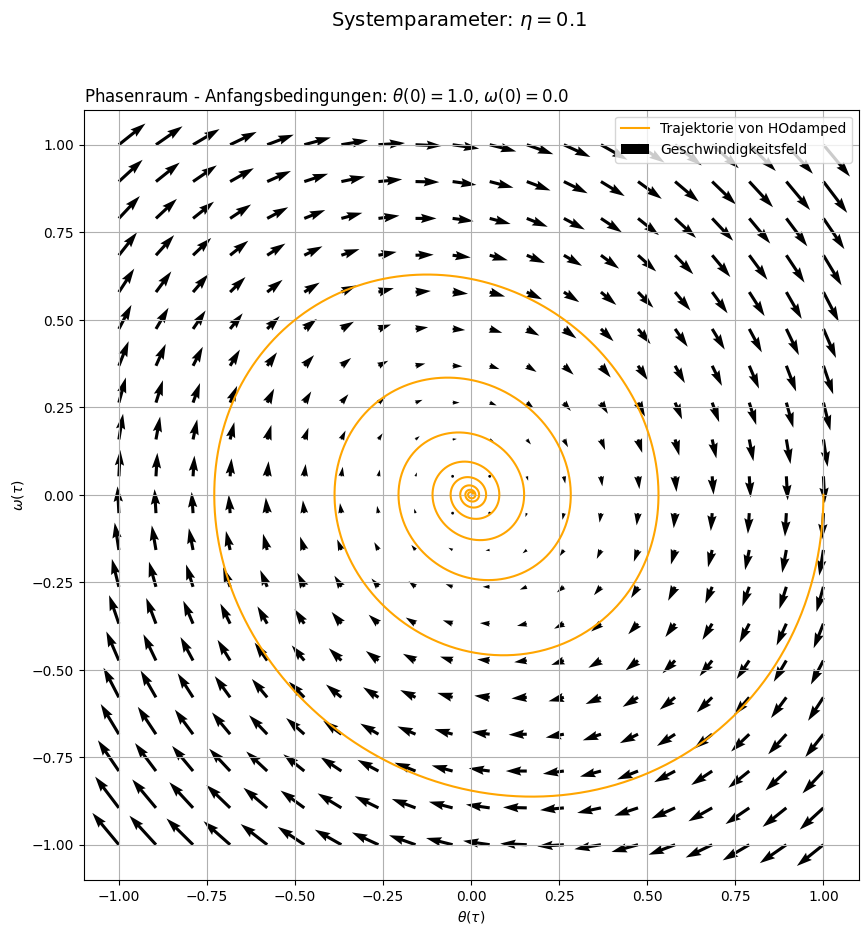

In [5]:
import sys
import matplotlib.pyplot as plt
### Oszillator-Parameter
eta = 0.1
### Vektor mit Anfangsbedingungen für das Geschwindigkeitsfeld
x_ini = 1.0
v_ini = 0.0
iniVal = np.array([x_ini, v_ini])
### Startzeit und maximale Zeitspanne
t_ini = 0.0 
t_fin = 50
### Samplingfrequenz [Punkte/s]
fSam = 100
### Anzahl der erzeugten Punkte
N = int(t_fin * fSam)
### Array mit N äquidistanten Zeitpunkten
t = np.linspace(t_ini,t_fin, N+1)
### Initialisierung des Geschwindigkeitsfeldes:
fHOdampedRes = np.zeros((len(t), 2))
### Lösen des DGLn 1. Ordnung-Systems:
fHOdampedRes = odeint(f_HOdamped, iniVal, t, args=(eta,))

## 2D-Vektorfeld
resolution = 20
t_2D = np.linspace(t_ini,t_fin,resolution)
#print("t_2D", t_2D)
x,y = np.meshgrid(np.linspace(-1,1,resolution),np.linspace(-1,1,resolution))
u = y
v = -2*eta*y - x
#print("u", u)

tPlot_ini = 0
# Phasenraum-Plots
fig, ax = plt.subplots(1, 1,  figsize=(10, 10))
fig.suptitle(r"Systemparameter: $\eta={}$".format(eta), fontsize=14)
ax.set_title(r"Phasenraum - Anfangsbedingungen: $\theta(0) = {}$, $\omega(0) = {}$".format(x_ini, v_ini), loc='left')
ax.plot(fHOdampedRes[tPlot_ini:, 0], fHOdampedRes[tPlot_ini:, 1], color="orange" ,label=r"Trajektorie von HOdamped")
ax.quiver(x,y,u,v, width=0.004, label=r"Geschwindigkeitsfeld")
ax.legend(loc='best')
ax.set_xlabel(r"$\theta (\tau)$")
ax.set_ylabel(r"$\omega (\tau)$")
ax.grid()

<div style=" border: 2px solid green;margin: 10px auto; padding: 10px; border-radius: 10px; background-color: beige;">
<div style="text-align: justify">
Die Phasenraumtrajektorie folgt gut sichtbar dem Geschwindigkeitsvektorfeld und konvergiert nach endlicher Zeit in einem Punktattraktor, dem Ursrpung.
</div>

<hr style="width:50%">
<div style= "color: black;background-color: #d6eaf8 ;margin: 10 px auto; padding: 10px; border-radius: 10px">
<p style="font-size:12pt; text-align:center; color:   black; background-color: lightskyblue ;margin: 10 px auto; padding: 10px; border-radius: 10px" id="1"><b>  Aufgabe 4 </b> </p> 
<div style="text-align: justify">    
Gegeben ist das nicht-lineare dynamische System aus Gl. (4). Verwenden Sie zur Lösung der DGLn wieder die <code>odeint</code>-Funktion aus dem <code>SciPy</code>-Paket.<br/>
<br>
<b>Teilaufgabe a)</b><br/>
Definieren Sie hierzu eine Funktion <code>f_DO</code>, welche das Geschwindigkeitsfeld aus Gl. (6) berechnet und die folgenden Parameter entgegennimmt : <code>iniVal</code> (Array mit Anfangsbedingungen), <code>t</code> (Zeitintervall, startend bei 0), weitere Systemparameter.<br><br/>
<b>Teilaufgabe b)</b><br/>
Definieren Sie auch mit Hilfe der Gl. (4) eine Geschwindigkeitsfeld-Funktion <code>f_HO</code> für den gedämpften getriebenen harmonischen Oszillator. <br><br/>
<b>Teilaufgabe c)</b><br/>
Lösen Sie beide DGLn numerisch. Betrachten Sie hierbei ein Zeitintervall (mit geeigneter Auflösung) von 10 Perdioden bezüglich der externen Frequenz. Erstellen Sie zwei $\theta(\tau)$-$\omega(\tau)$-Phasenraumdiagramme mit den Trajektorien beider Oszillatoren (verwenden Sie unterschiedliche Farben) für die folgenden Systemparameter und Anfangsbedingungen:
 <ol>
  <li>$\eta = 0.2$, $\epsilon = 0.01$, $\sigma = 1$, $\theta (0) = 1.0$ und $\omega(0) = 0.0~,$ sowie </li>
  <li>$\eta = 0.2$, $\epsilon = 0.01$, $\sigma = 1$, $\theta (0) = 6.0$ und $\omega(0) = 0.0~.$</li>
</ol>
Geschwindigkeitsfelder müssen in dieser Aufgabe nicht geplottet werden.<br><br/>
Was beobachten Sie?
</div>
</div>    

**a)**

In [6]:
def f_DO(iniVal, t, eta, epsilon, sigma):
    fDOres = np.zeros_like(iniVal)
    x = iniVal[0]
    v = iniVal[1]
    fDOres[0] = v
    fDOres[1] = -2*eta*v - x - epsilon*x**3 + np.cos(sigma*t)
    
    return fDOres

**b)** 

In [7]:
def f_HO(iniVal, t, eta, sigma):
    fHOres = np.zeros_like(iniVal)
    x = iniVal[0]
    v = iniVal[1]
    fHOres[0] = v
    fHOres[1] = -2*eta*v - x + np.cos(sigma*t)
    
    return fHOres

**c)**

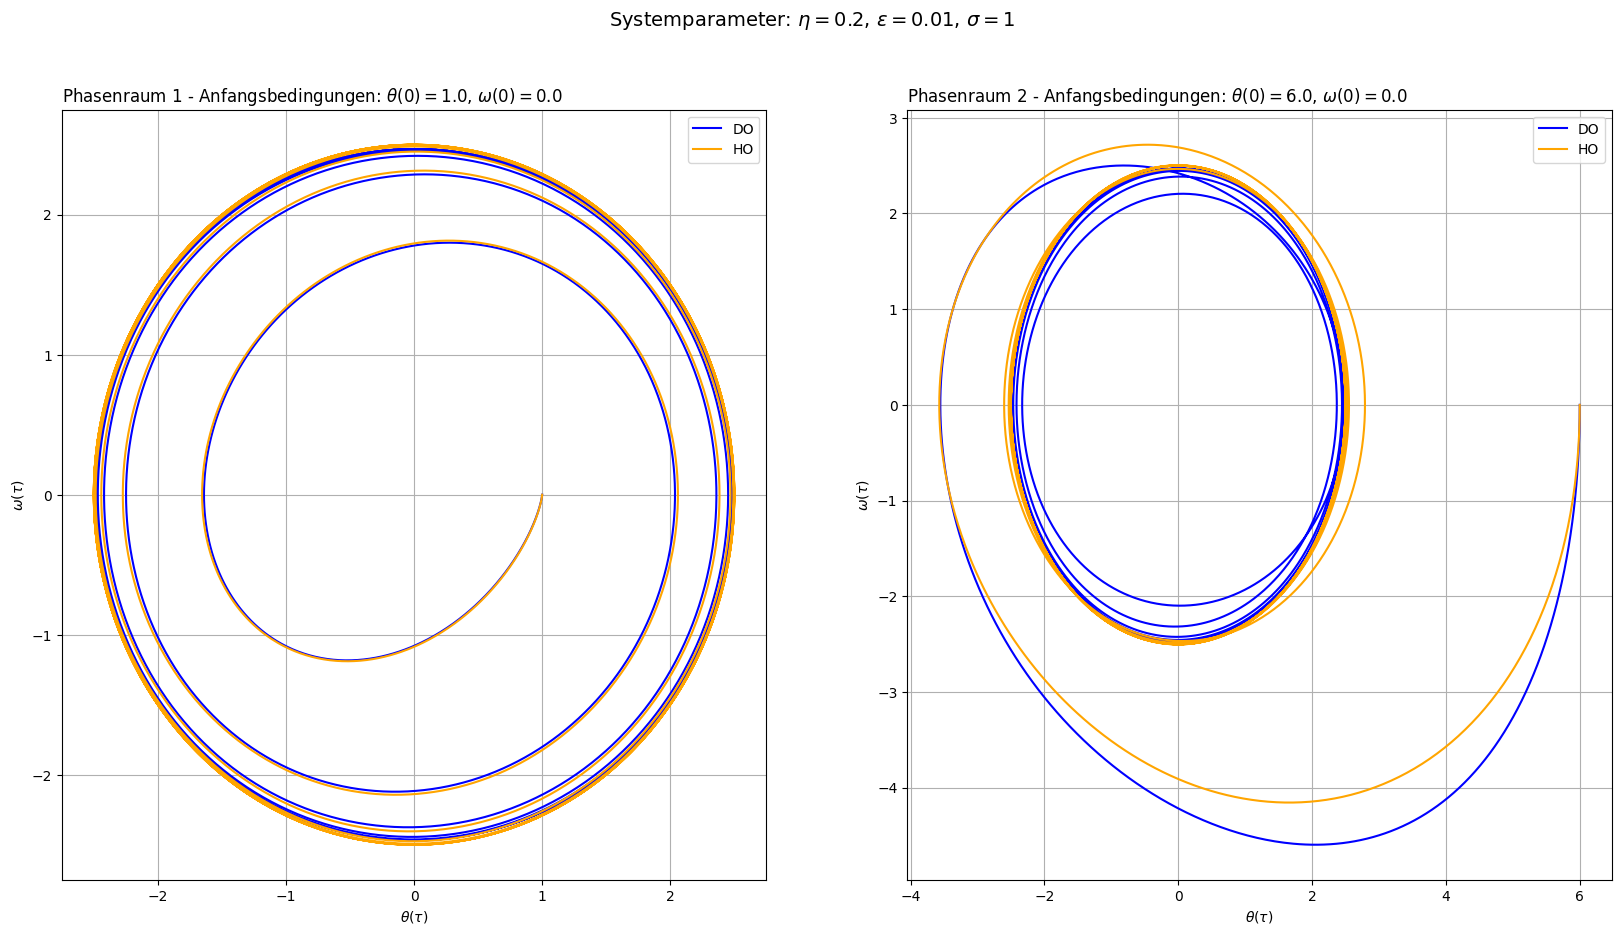

In [8]:
import sys
### Oszillator-Parameter
eta1 = 0.2
epsilon1 = 0.01
sigma1 = 1
### Vektor mit Anfangsbedingungen für das Geschwindigkeitsfeld
x_ini1A = 1.0
v_ini1A = 0.0
iniVal1A = np.array([x_ini1A, v_ini1A])
x_ini1B = 6.0
v_ini1B = v_ini1A 
iniVal1B = np.array([x_ini1B, v_ini1B])
### Periode des Systems
Text1 = 2*np.pi / sigma1
### Startzeit und maximale Zeitspanne
t_ini1 = 0.0 
t_fin1 = 10 * Text1
### Samplingfrequenz [Punkte/s]
fSam1 = 100
### Anzahl der erzeugten Punkte
N1 = int(t_fin1 * fSam1)
### Array mit N äquidistanten Zeitpunkten
t1 = np.linspace(t_ini1,t_fin1, N1+1)
### Initialisierung des Geschwindigkeitsfeldes:
fDOres1 = np.zeros((len(t1), 2))
fHOres1 = np.zeros((len(t1), 2))
fDOres2 = np.zeros((len(t1), 2))
fHOres2 = np.zeros((len(t1), 2))
### Lösen des DGLn 1. Ordnung-Systems:
fDOres1 = odeint(f_DO, iniVal1A, t1, args=(eta1, epsilon1, sigma1))
fHOres1 = odeint(f_HO, iniVal1A, t1, args=(eta1, sigma1))
fDOres2 = odeint(f_DO, iniVal1B, t1, args=(eta1, epsilon1, sigma1))
fHOres2 = odeint(f_HO, iniVal1B, t1, args=(eta1, sigma1))

tPlot_ini1 = 0
# Phasenraum-Plots
fig1, (axA1, axB1) = plt.subplots(1, 2,  figsize=(20, 10))
fig1.suptitle(r"Systemparameter: $\eta={}$, $\epsilon={}$, $\sigma={}$".format(eta1,epsilon1,sigma1), fontsize=14)
axA1.set_title(r"Phasenraum 1 - Anfangsbedingungen: $\theta(0) = {}$, $\omega(0) = {}$".format(x_ini1A, v_ini1A), loc='left')
axA1.plot(fDOres1[tPlot_ini1:, 0], fDOres1[tPlot_ini1:, 1], color="blue" ,label=r"DO")
axA1.plot(fHOres1[tPlot_ini1:, 0], fHOres1[tPlot_ini1:, 1], color="orange" ,label=r"HO")
axA1.legend(loc='best')
axA1.set_xlabel(r"$\theta (\tau)$")
axA1.set_ylabel(r"$\omega (\tau)$")
axA1.grid()
axB1.set_title(r"Phasenraum 2 - Anfangsbedingungen: $\theta(0) = {}$, $\omega(0) = {}$".format(x_ini1B, v_ini1B), loc='left')
axB1.plot(fDOres2[tPlot_ini1:, 0], fDOres2[tPlot_ini1:, 1], color="blue" ,label=r"DO")
axB1.plot(fHOres2[tPlot_ini1:, 0], fHOres2[tPlot_ini1:, 1], color="orange" ,label=r"HO")
axB1.legend(loc='best')
axB1.set_xlabel(r"$\theta (\tau)$")
axB1.set_ylabel(r"$\omega (\tau)$")
axB1.grid()

<div style=" border: 2px solid green;margin: 10px auto; padding: 10px; border-radius: 10px; background-color: beige;">
<div style="text-align: justify">
Für kleine Auslekungen verhalten sich, wie erwartet, beide Oszillatoren gleich (li. Plot). Für größere Auslenkungen weicht der nicht-lineare DO vom linearen HO ab. Beide Phasenraum-Trajektorien sind daher nicht mehr kongruent (re. Plot).
</div>

<hr style="width:50%">
<div style="text-align: justify">
Spezielle nicht-lineare Gleichungen haben außerdem eine weitere in der Natur häufig zu findende Eigenschaft : Unter den richtigen Bedingungen zeigen sie <i>chaotisches Verhalten</i>. Es gibt zwei notwendige Bedingungen, die erfüllt sein müssen, damit chaotisches Verhalten überhaupt zustande kommt:
 <ol>
  <li>Sie enthalten mindestens drei unabhängige dynamische Variablen.</li>
  <li>Sie sind nicht-linear.</li>
</ol> 
Beide Bewegungsgleichungen $\big($gedämpftes, getriebenes Pendel, Gl. (1) und Duffing-Oszillator, Gl. (3) $\big)$ erfüllen die Bedingungen für chaotisches Verhalten mit jeweils drei Variablen $\big((\theta(t),~ \dot{\theta}(t),~ \phi(t) \big)$, wobei $\phi(t)= \omega_{\text{ext}} t$ die Phase der externen Kraft bezeichnet. Ob die Bewegung chaotisch ist, hängt von den Werten der Systemparameter ab. Im Folgenden werden wir uns komplett auf den Duffing-Oszillator konzentrieren. Um Phasendiagramme komplizierter Systeme vereinfacht darstellen zu können bedienen wir uns des Konzeptes von <strong>Poincare-Schnitten</strong>.
</div>

<div style=" border: 2px solid black; margin: 10px auto; padding: 10px; border-radius: 10px; background-color: #f4ecf7;">
    <b>Poincare-Schnitte und Attraktoren</b> 
<ul>     
<div style="text-align: justify">
Ein Poincare-Schnitt ist am ehesten zu veranschaulichen mit einer Stroboskopaufnahme einer Phasenraumtrajektorie. Für die Erzeugung solcher Schnitte wählt man üblicherweise Zeitpunkte, die ein Vielfaches der Eigenfrequenz, oder bei getriebenen Systemen, der Erregerfrequenz entsprechen. Das Ziel dieser Abbildung ist, Strukturen von Attraktoren zu entdecken. Attraktoren sind Häufungsmengen (Untermengen) des Phasenraums auf die das System für $t \longrightarrow \infty$ asymptotisch zuläuft. In komplexen Systemen können diese beliebig komplizierte Formen annehmen.
</div>    
<ul> 
</div>

<div style="text-align: justify">
Eine weitere Duffing-DGL, deren Lösungen einige interessante Phänomene aufweisen können, wie z.B. Periodenverdopplung oder Chaos, ist gegeben durch
</div><br/>
    
\begin{equation*}
\theta^{\prime \prime}(\tau) + 2 \eta \theta^{\prime}(\tau) - \theta(\tau) + \epsilon \theta^3(\tau) = \cos (\sigma \tau) \qquad \text{mit} \qquad \tau = \sqrt{-\alpha}t,~ ~ \alpha= - |\alpha_0| < 0, ~ ~ \beta > 0~.
\label{eq:Duffing_scaledNegAlpha}\tag{7}
\end{equation*}

<div style="text-align: justify">    
Wie schon weiter oben besprochen, werden wir uns mit der Parameterwahl aus Gleichung $\eqref{eq:Duffing_scaledNegAlpha}$ komplett vom physikalischen Fadenpendel distanzieren. Des Weiteren besitzt das hier zu untersuchende dynamische System (in Abwesenheit der dissipativen und treibenden Kraft) ein interessantes Potential. Können Sie die Form des Potentials erraten?
</div><br/>    

<div style= "color: black;background-color: #d6eaf8 ;margin: 10 px auto; padding: 10px; border-radius: 10px">
<p style="font-size:12pt; text-align:center; color:   black; background-color: lightskyblue ;margin: 10 px auto; padding: 10px; border-radius: 10px" id="1"><b>  Aufgabe 5 </b> </p> 
<div style="text-align: justify">    
Gegeben ist nun das nicht-lineare dynamische System aus Gl. $\eqref{eq:Duffing_scaledNegAlpha}$ mit den Anfangsbedingungen $\theta(0) = 0.9$, $\omega(0) = 0.0$ und den Systemparametern $\eta = 0.15$ und $\sigma = 1.2.$ Der Parameter $\epsilon$ wird jedoch variiert und soll die folgenden Werte annehmen: $\{ 0.04,~ ~ 0.0784,~ ~ 0.1369,~ ~ 0.25 \}$ . <br><br/> 
<b>Teilaufgabe a)</b><br/>
Definieren Sie hierfür eine neue Funktion <code>f_DO_chaos</code> und verwenden Sie diese für die komplette Aufgabe. <br><br/>
<b>Teilaufgabe b)</b><br/>
Gehen Sie nacheinander die folgenden Schritte durch und kommentieren Sie Ihre Plots:
 <ol>
  <li>Untersuchen Sie die Zeitentwicklung des Systems und ermitteln Sie anschließend den Zeitpunkt nach dem das transiente Verhalten abgeklungen ist.
  <li>Definieren Sie für die Darstellung der Poincare-Schnitte ein geeignetes Zeitintervall mit maximal 80 Perdioden bezüglich der externen Frequenz.</li>
  <li>Plotten Sie nebeneinander für jeden $\epsilon$-Wert sowohl die Zeitentwicklung der Amplitude als auch das entsprechende Phasenraumdiagramm, welches gleichzeitig die Phasenraumtrajektorie und den Poincare-Schnitt im eingeschwungenem Zustand darstellt. Verwenden Sie für die Darstellung der Poincare-Schnitte die Funktion <code>pyplot.scatter</code> (<a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html">scatter-Doc</a>).</li>
  <li>Was bewirkt die Änderung des $\epsilon$-Wertes? Kommentieren Sie Ihre Beobachtungen.</li>
</ol> 
</div>
</div>    

**a)**

In [9]:
def f_DO_chaos(iniVal, t, eta, epsilon, sigma):
    fDOres = np.zeros_like(iniVal)
    x = iniVal[0]
    v = iniVal[1]
    fDOres[0] = v
    fDOres[1] = -2*eta*v + x - epsilon*x**3 + np.cos(sigma*t)
    
    return fDOres

**b)**

In [10]:
# skalierter DO mit alpha < 0 und beta > 0
eta2 = 0.15
sigma2 = 1.2
#epsilon wird variiert
### Anfangsbedingungen
x_ini2 = 0.9
v_ini2 = 0.0
iniVal2 = np.array([x_ini2, v_ini2])
### Periode des Systems
Text2 = 2*np.pi / sigma2
### Startzeit und maximale Zeitspanne
t_ini2 = 0.0 
t_fin2 = 80 * Text2
### Samplingfrequenz [Punkte/s]
fSam2 = 80
### Anzahl der erzeugten Punkte
N2 = int(t_fin2 * fSam2)
### Array mit N äquidistanten Zeitpunkten
t2 = np.linspace(t_ini2,t_fin2, N2)
tPlot_ini2 = 18*Text2
index_tPlot_ini2 = int(tPlot_ini2 * fSam2)

### Strobo-Zeitpunkte
tPS_ini2 = 0
n2=79
tPS_fin2 = n2 * Text2
tPS2 = np.linspace(tPS_ini2, tPS_fin2, n2+1)
index_PS2 = 18

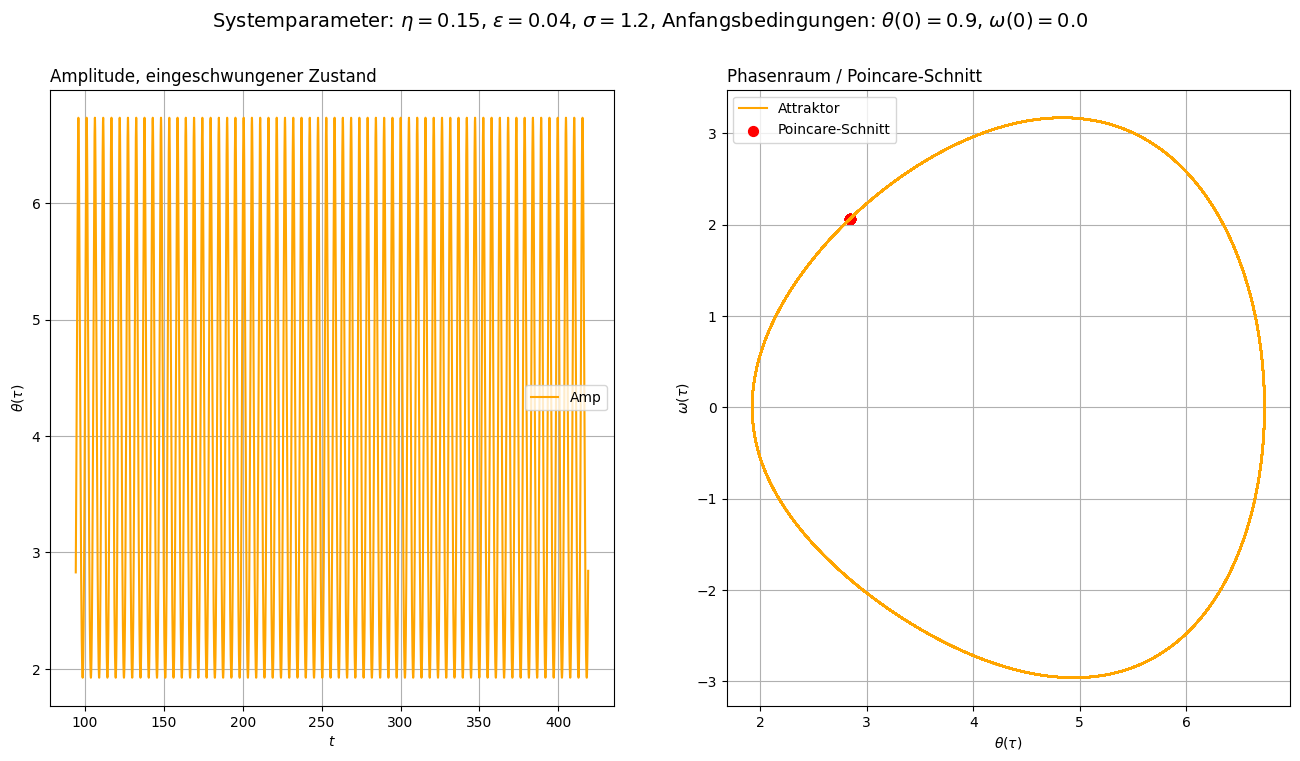

In [11]:
epsilonA = 0.04
fDOchaosA = np.zeros((len(t2), 2))
fDOchaosPSA = np.zeros((len(t2), 2))
fDOchaosA = odeint(f_DO_chaos, iniVal2, t2, args=(eta2, epsilonA, sigma2))
fDOchaosPSA = odeint(f_DO_chaos, iniVal2, tPS2, args=(eta2, epsilonA, sigma2))

fig2, (ax2A1, ax2A2) = plt.subplots(1, 2,  figsize=(16, 8))
fig2.suptitle(r"Systemparameter: $\eta={}$, $\epsilon={}$, $\sigma={}$, Anfangsbedingungen: $\theta(0)={}$, $\omega(0)={}$".format(eta2,epsilonA,sigma2,x_ini2,v_ini2), fontsize=14)
ax2A1.set_title(r"Amplitude, eingeschwungener Zustand", loc='left')
ax2A1.plot(t2[index_tPlot_ini2:], fDOchaosA[index_tPlot_ini2:, 0], color="orange" ,label=r"Amp")
#ax2A1.set_xlim([-1.6, 1.6])
#ax2A1.set_ylim([-1.2, 1.2])
ax2A1.legend(loc='best')
ax2A1.set_xlabel(r"$t$")
ax2A1.set_ylabel(r"$\theta (\tau)$")
ax2A1.grid()
ax2A2.set_title(r"Phasenraum / Poincare-Schnitt", loc='left')
ax2A2.plot(fDOchaosA[index_tPlot_ini2:, 0], fDOchaosA[index_tPlot_ini2:, 1], color="orange" ,label=r"Attraktor")
ax2A2.scatter(fDOchaosPSA[index_PS2:, 0], fDOchaosPSA[index_PS2:, 1], s=50, color="red", label=r"Poincare-Schnitt")
#ax2A2.set_xlim([-1.6, 1.6])
#ax2A2.set_ylim([-1.2, 1.2])
ax2A2.legend(loc='best')
ax2A2.set_xlabel(r"$\theta (\tau)$")
ax2A2.set_ylabel(r"$\omega (\tau)$")
ax2A2.grid()

<div style=" border: 2px solid green;margin: 10px auto; padding: 10px; border-radius: 10px; background-color: beige;">
<div style="text-align: justify">
Nachdem das transiente Verhalten abgeklungen ist (für $\tau > 18 \cdot T_{\sigma}$), bestätigt das Phasenraumdiagramm die Existenz einer $\dfrac{2 \pi}{\sigma}$-periodischen Lösung für $\tau \rightarrow \infty$. Der Poicare-Schnitt besteht somit nur aus einem, auf der Trajektorie liegenden, Punkt.
</div>

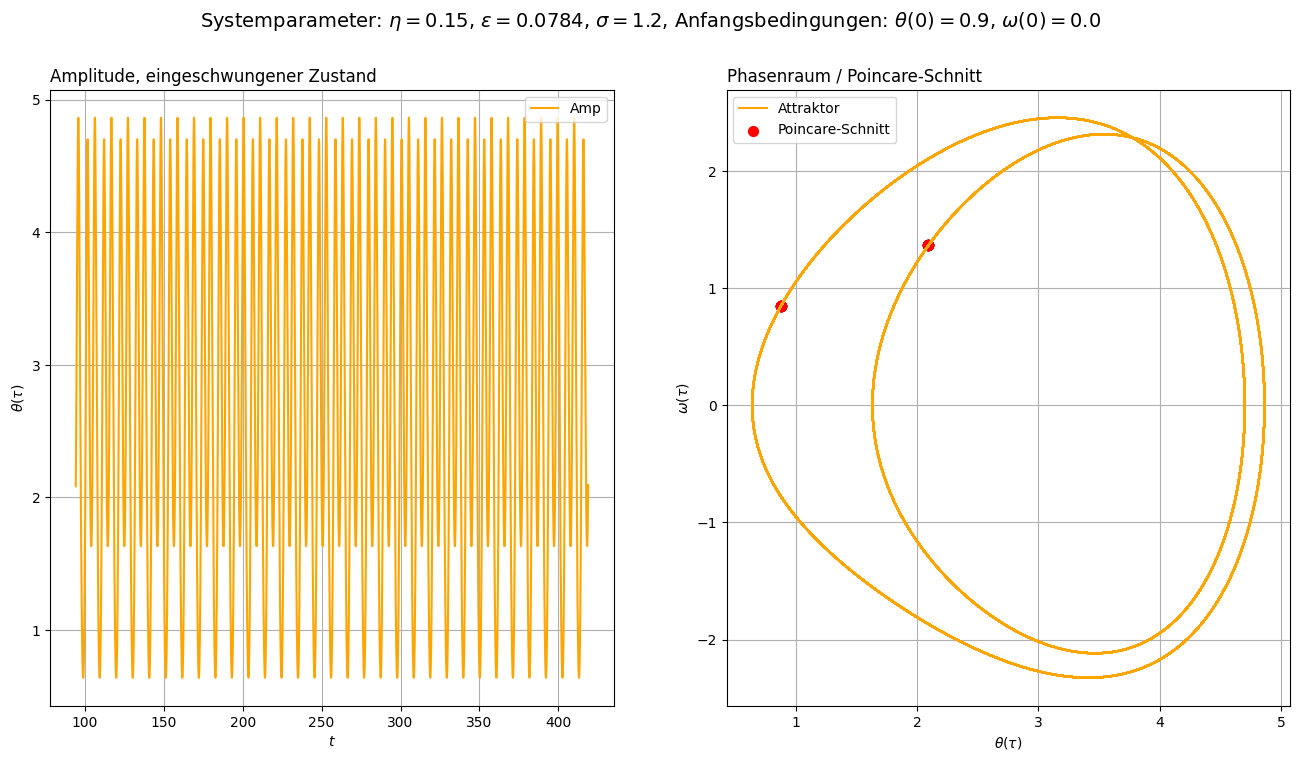

In [12]:
epsilonB = 0.0784
fDOchaosB = np.zeros((len(t2), 2))
fDOchaosPSB = np.zeros((len(t2), 2))
fDOchaosB = odeint(f_DO_chaos, iniVal2, t2, args=(eta2, epsilonB, sigma2))
fDOchaosPSB = odeint(f_DO_chaos, iniVal2, tPS2, args=(eta2, epsilonB, sigma2))
fig3, (ax2B1, ax2B2) = plt.subplots(1, 2,  figsize=(16, 8))
fig3.suptitle(r"Systemparameter: $\eta={}$, $\epsilon={}$, $\sigma={}$, Anfangsbedingungen: $\theta(0)={}$, $\omega(0)={}$".format(eta2,epsilonB,sigma2,x_ini2,v_ini2), fontsize=14)
ax2B1.set_title(r"Amplitude, eingeschwungener Zustand", loc='left')
ax2B1.plot(t2[index_tPlot_ini2:], fDOchaosB[index_tPlot_ini2:, 0], color="orange" ,label=r"Amp")
#ax2B1.set_xlim([-1.6, 1.6])
#ax2B1.set_ylim([-1.2, 1.2])
ax2B1.legend(loc='best')
ax2B1.set_xlabel(r"$t$")
ax2B1.set_ylabel(r"$\theta (\tau)$")
ax2B1.grid()
ax2B2.set_title(r"Phasenraum / Poincare-Schnitt", loc='left')
ax2B2.plot(fDOchaosB[index_tPlot_ini2:, 0], fDOchaosB[index_tPlot_ini2:, 1], color="orange" ,label=r"Attraktor")
ax2B2.scatter(fDOchaosPSB[index_PS2:, 0], fDOchaosPSB[index_PS2:, 1], s=50, color="red", label=r"Poincare-Schnitt")
#ax2B2.set_xlim([-1.6, 1.6])
#ax2B2.set_ylim([-1.2, 1.2])
ax2B2.legend(loc='best')
ax2B2.set_xlabel(r"$\theta (\tau)$")
ax2B2.set_ylabel(r"$\omega (\tau)$")
ax2B2.grid()

<div style=" border: 2px solid green;margin: 10px auto; padding: 10px; border-radius: 10px; background-color: beige;">
<div style="text-align: justify">
Beginnend bei $\tau > 18 \cdot T_{\sigma}$, bestätigt das Phasenraumdiagramm die Existenz einer $2 \cdot \dfrac{2 \pi}{\sigma}$-periodischen Lösung (Periodenverdopplung) für $\tau \rightarrow \infty$. Der Poicare-Schnitt besteht somit aus zwei, auf der Trajektorie liegenden, Punkten.
</div>
</div>

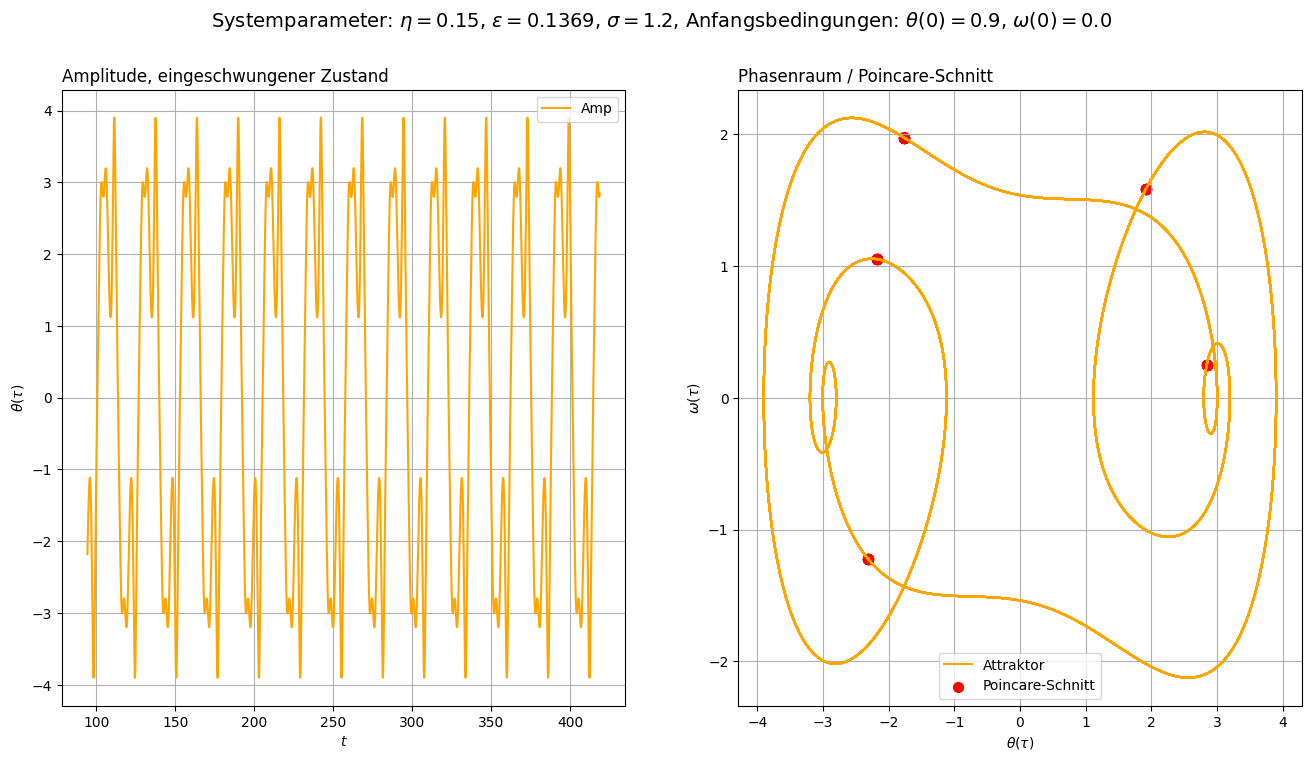

In [13]:
epsilonC = 0.1369
fDOchaosC = np.zeros((len(t2), 2))
fDOchaosPSC = np.zeros((len(t2), 2))
fDOchaosC = odeint(f_DO_chaos, iniVal2, t2, args=(eta2, epsilonC, sigma2))
fDOchaosPSC = odeint(f_DO_chaos, iniVal2, tPS2, args=(eta2, epsilonC, sigma2))
fig4, (ax2C1, ax2C2) = plt.subplots(1, 2,  figsize=(16, 8))
fig4.suptitle(r"Systemparameter: $\eta={}$, $\epsilon={}$, $\sigma={}$, Anfangsbedingungen: $\theta(0)={}$, $\omega(0)={}$".format(eta2,epsilonC,sigma2,x_ini2,v_ini2), fontsize=14)
ax2C1.set_title(r"Amplitude, eingeschwungener Zustand", loc='left')
ax2C1.plot(t2[index_tPlot_ini2:], fDOchaosC[index_tPlot_ini2:, 0], color="orange" ,label=r"Amp")
#ax2C1.set_xlim([-1.6, 1.6])
#ax2C1.set_ylim([-1.2, 1.2])
ax2C1.legend(loc='best')
ax2C1.set_xlabel(r"$t$")
ax2C1.set_ylabel(r"$\theta (\tau)$")
ax2C1.grid()
ax2C2.set_title(r"Phasenraum / Poincare-Schnitt", loc='left')
ax2C2.plot(fDOchaosC[index_tPlot_ini2:, 0], fDOchaosC[index_tPlot_ini2:, 1], color="orange" ,label=r"Attraktor")
ax2C2.scatter(fDOchaosPSC[index_PS2:, 0], fDOchaosPSC[index_PS2:, 1], s=50, color="red", label=r"Poincare-Schnitt")
#ax2C2.set_xlim([-1.6, 1.6])
#ax2C2.set_ylim([-1.2, 1.2])
ax2C2.legend(loc='best')
ax2C2.set_xlabel(r"$\theta (\tau)$")
ax2C2.set_ylabel(r"$\omega (\tau)$")
ax2C2.grid()

<div style=" border: 2px solid green;margin: 10px auto; padding: 10px; border-radius: 10px; background-color: beige;">
<div style="text-align: justify">
Beginnend bei $\tau > 18 \cdot T_{\sigma}$, bestätigt das Phasenraumdiagramm die Existenz einer $5 \cdot \dfrac{2 \cdot \pi}{\sigma}$-periodischen Lösung (Periodenverfünffachung) für $\tau \rightarrow \infty$. Der Poicare-Schnitt besteht somit aus fünf, auf der Trajektorie liegenden, Punkten.
</div>
</div>

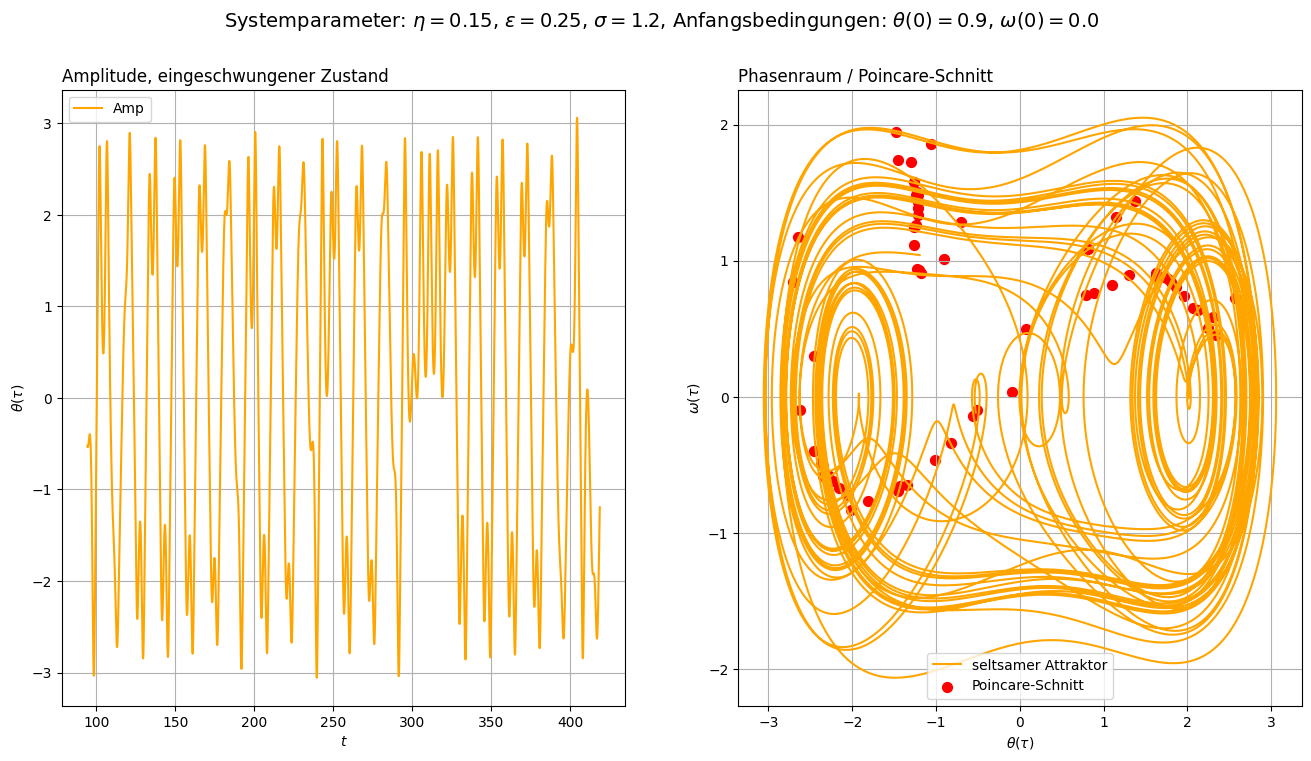

In [14]:
epsilonD = 0.25
fDOchaosD = np.zeros((len(t2), 2))
fDOchaosPSD = np.zeros((len(t2), 2))
fDOchaosD = odeint(f_DO_chaos, iniVal2, t2, args=(eta2, epsilonD, sigma2))
fDOchaosPSD = odeint(f_DO_chaos, iniVal2, tPS2, args=(eta2, epsilonD, sigma2))
fig5, (ax2D1, ax2D2) = plt.subplots(1, 2,  figsize=(16, 8))
fig5.suptitle(r"Systemparameter: $\eta={}$, $\epsilon={}$, $\sigma={}$, Anfangsbedingungen: $\theta(0)={}$, $\omega(0)={}$".format(eta2,epsilonD,sigma2,x_ini2,v_ini2), fontsize=14)
ax2D1.set_title(r"Amplitude, eingeschwungener Zustand", loc='left')
ax2D1.plot(t2[index_tPlot_ini2:], fDOchaosD[index_tPlot_ini2:, 0], color="orange" ,label=r"Amp")
#ax2D1.set_xlim([-1.6, 1.6])
#ax2D1.set_ylim([-1.2, 1.2])
ax2D1.legend(loc='best')
ax2D1.set_xlabel(r"$t$")
ax2D1.set_ylabel(r"$\theta (\tau)$")
ax2D1.grid()
ax2D2.set_title(r"Phasenraum / Poincare-Schnitt", loc='left')
ax2D2.plot(fDOchaosD[index_tPlot_ini2:, 0], fDOchaosD[index_tPlot_ini2:, 1], color="orange" ,label=r"seltsamer Attraktor")
ax2D2.scatter(fDOchaosPSD[index_PS2:, 0], fDOchaosPSD[index_PS2:, 1], s=50, color="red", label=r"Poincare-Schnitt")
#ax2D2.set_xlim([-1.6, 1.6])
#ax2D2.set_ylim([-1.2, 1.2])
ax2D2.legend(loc='best')
ax2D2.set_xlabel(r"$\theta (\tau)$")
ax2D2.set_ylabel(r"$\omega (\tau)$")
ax2D2.grid()

<div style=" border: 2px solid green;margin: 10px auto; padding: 10px; border-radius: 10px; background-color: beige;">
<div style="text-align: justify">
Für $\tau > 18 \cdot T_{\sigma}$ zeigt das Phasenraumdiagramm die Trajektorien eines chaotischen Systems an. Der Poicare-Schnitt eines solchen Systems besteht normalerweise aus einer unendlichen Anzahl von Punkten (hier: Beobachtungszeit ist zu kurz). In diesem Regime ist die Bewegung stark von den Anfangsbedingungen abhängig und weist somit keine feste Wiederholungsdauer auf.
</div>
</div>

<hr style="width:50%">
<div style= "color: black;background-color: #d6eaf8 ;margin: 10 px auto; padding: 10px; border-radius: 10px">
<p style="font-size:12pt; text-align:center; color:   black; background-color: lightskyblue ;margin: 10 px auto; padding: 10px; border-radius: 10px" id="1"><b>  Aufgabe 6 </b>  </p> 
<div style="text-align: justify">
Erstellen Sie einen Poincare-Schnitt für $\eta = 0.15$, $\epsilon = 0.25$ und $\sigma = 1.2$ mit maximal 2000 Perioden bezüglich der externen Frequenz im eingeschwungenem Zustand. Kommentieren Sie den Plot.
</div>    
</div>    

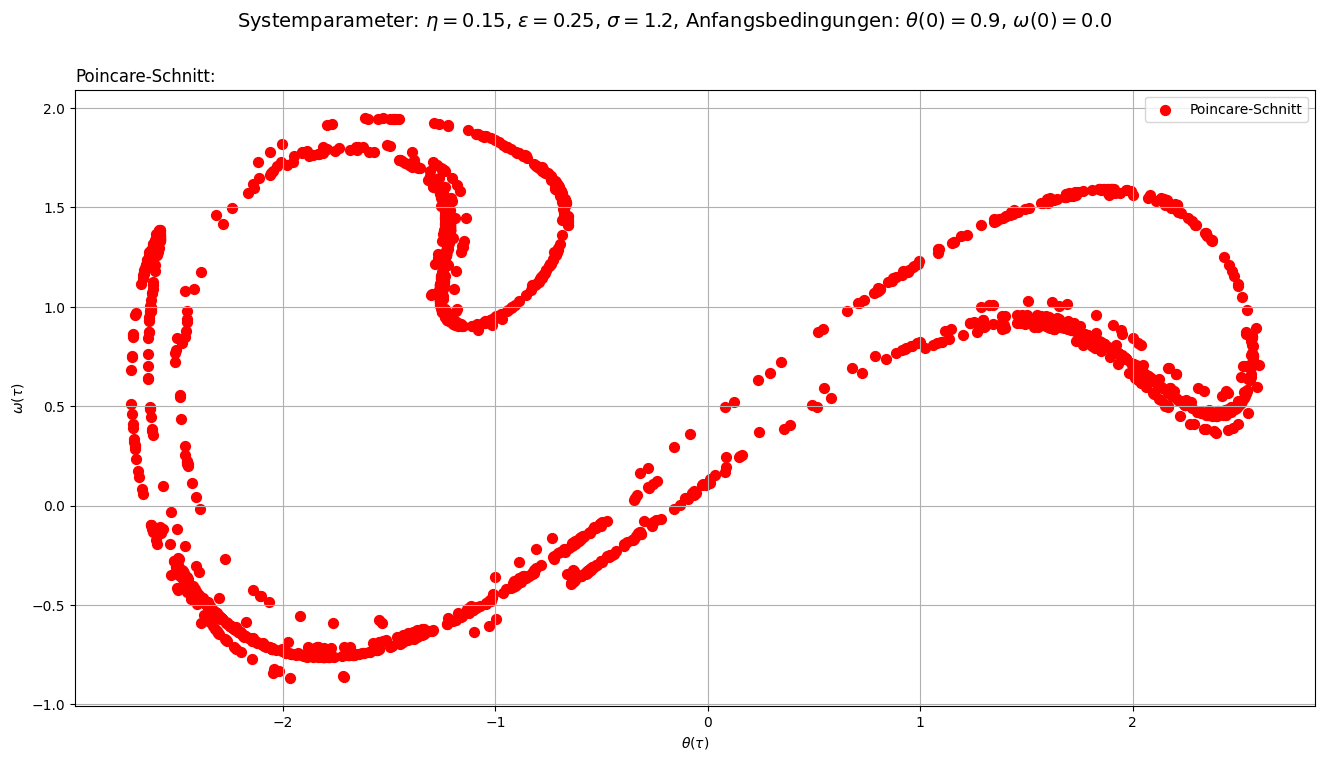

In [15]:
### Strobo-Zeitpunkte
tPS_ini3 = 0
n3=2000
tPS_fin3 = n3 * Text2
tPS3 = np.linspace(tPS_ini3, tPS_fin3, n3+1)
index_PS2 = 18
epsilonD = 0.25
fDOchaosPSE = np.zeros((len(t2), 2))
fDOchaosPSE = odeint(f_DO_chaos, iniVal2, tPS3, args=(eta2, epsilonD, sigma2))
fig6, ax2E = plt.subplots(1, 1,  figsize=(16, 8))
fig6.suptitle(r"Systemparameter: $\eta={}$, $\epsilon={}$, $\sigma={}$, Anfangsbedingungen: $\theta(0)={}$, $\omega(0)={}$".format(eta2,epsilonD,sigma2,x_ini2,v_ini2), fontsize=14)
ax2E.set_title(r"Poincare-Schnitt:", loc='left')
ax2E.scatter(fDOchaosPSE[index_PS2:, 0], fDOchaosPSE[index_PS2:, 1], s=50, color="red", label=r"Poincare-Schnitt")
#ax2E.set_xlim([-1.6, 1.6])
#ax2E.set_ylim([-1.2, 1.2])
ax2E.legend(loc='best')
ax2E.set_xlabel(r"$\theta (\tau)$")
ax2E.set_ylabel(r"$\omega (\tau)$")
ax2E.grid()

<div style=" border: 2px solid green;margin: 10px auto; padding: 10px; border-radius: 10px; background-color: beige;">
<div style="text-align: justify">
Für eine längere Beobachtungsdauer des chaotischen Systems aus Aufgabe 5, zeigt der Poincare-Schnitt eine fraktale Struktur an. Solche Objekte nennt man seltsame Attraktoren.
</div>
</div>